In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image1317.png
/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image1268.png
/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image745.png
/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image883.png
/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image869.png
/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image291.png
/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image1446.png
/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image1245.png
/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image1214.png
/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image378.png
/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/diabetes/image762.png
/kaggle/input/da

In [2]:
!pip install timm -q

In [3]:
import os
import torch
import timm
import numpy as np

import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [4]:
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

2
Tesla T4


In [7]:
DATASET_PATH = "/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets"

In [11]:
IMG_SIZE = 224
BATCH_SIZE = 4

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

In [12]:
full_dataset = datasets.ImageFolder(
    DATASET_PATH,
    transform=train_transform
)

print(full_dataset.classes)
print(len(full_dataset))

['ageDegeneration', 'cataract', 'diabetes', 'glaucoma', 'hypertension', 'myopia', 'normal', 'others']
6392


In [39]:
train_size = int(0.8 * len(full_dataset))
valid_size = len(full_dataset) - train_size

train_dataset, valid_dataset = random_split(
    full_dataset,
    [train_size, valid_size]
)

In [43]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [44]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(device)

cuda


In [45]:
NUM_CLASSES = len(full_dataset.classes)

model = timm.create_model(
    'resnet50',
    pretrained=False,
    num_classes=NUM_CLASSES
)

model = model.to(device)

In [46]:

print(next(model.parameters()).device)

cuda:0


In [47]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [49]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    preds_list = []
    labels_list = []

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        preds_list.extend(preds.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_list, preds_list)

    return running_loss / len(loader), acc

In [50]:
def validate(model, loader):

    model.eval()

    running_loss = 0

    preds_list = []
    labels_list = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_list, preds_list)

    return running_loss / len(loader), acc

In [51]:
EPOCHS = 30

best_acc = 0

for epoch in range(EPOCHS):

    print(f'\\nEpoch {epoch+1}/{EPOCHS}')

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    valid_loss, valid_acc = validate(
        model,
        valid_loader
    )

    print(f'Train Loss: {train_loss:.4f}')
    print(f'Train Acc : {train_acc:.4f}')

    print(f'Valid Loss: {valid_loss:.4f}')
    print(f'Valid Acc : {valid_acc:.4f}')

    if valid_acc > best_acc:

        best_acc = valid_acc

        torch.save(
            model.state_dict(),
            'best_model.pth'
        )

        print('Best model saved!')

\nEpoch 1/30


100%|██████████| 320/320 [00:05<00:00, 60.29it/s]


Train Loss: 1.2859
Train Acc : 0.5071
Valid Loss: 1.1086
Valid Acc : 0.5442
Best model saved!
\nEpoch 2/30


100%|██████████| 320/320 [00:05<00:00, 60.09it/s]


Train Loss: 1.1119
Train Acc : 0.5451
Valid Loss: 1.0527
Valid Acc : 0.5700
Best model saved!
\nEpoch 3/30


...

Train Loss: 0.6570
Train Acc : 0.7102
Valid Loss: 0.7940
Valid Acc : 0.6669
Best model saved!
\nEpoch 29/30


100%|██████████| 320/320 [00:05<00:00, 59.90it/s]


Train Loss: 0.6234
Train Acc : 0.7191
Valid Loss: 0.8793
Valid Acc : 0.6052
\nEpoch 30/30


100%|██████████| 320/320 [00:05<00:00, 59.68it/s]

Train Loss: 0.6051
Train Acc : 0.7311
Valid Loss: 0.8594
Valid Acc : 0.6521


In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def get_predictions(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

<Figure size 1000x800 with 0 Axes>

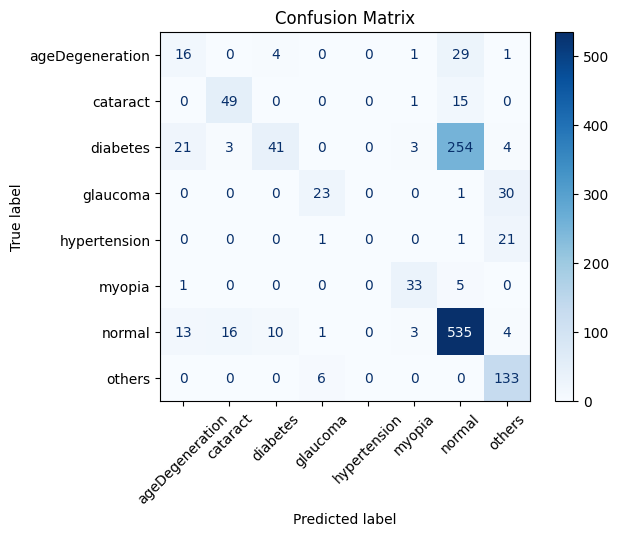

In [53]:
labels, preds = get_predictions(model, valid_loader)

cm = confusion_matrix(labels, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=full_dataset.classes
)

plt.figure(figsize=(10,8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [34]:
from torchvision import datasets
from PIL import Image

class CustomDataset(datasets.ImageFolder):

    def __init__(self, root, common_transform, rare_transform):
        super().__init__(root)
        self.common_transform = common_transform
        self.rare_transform = rare_transform

        # define rare classes
        self.rare_classes = ['glaucoma', 'hypertension', 'others']

    def __getitem__(self, index):

        path, label = self.samples[index]
        img = Image.open(path).convert("RGB")

        class_name = self.classes[label]

        # apply different transforms
        if class_name in self.rare_classes:
            img = self.rare_transform(img)
        else:
            img = self.common_transform(img)

        return img, label

In [35]:
common_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

rare_transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(25),

    transforms.ColorJitter(0.3,0.3,0.3),

    transforms.RandomAffine(
        degrees=15,
        translate=(0.1,0.1),
        scale=(0.9,1.1)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [36]:
full_dataset = CustomDataset(
    DATASET_PATH,
    common_transform=common_transform,
    rare_transform=rare_transform
)

In [37]:
train_dataset, valid_dataset = random_split(...)
train_loader = DataLoader(...)

TypeError: random_split() missing 1 required positional argument: 'lengths'

In [72]:
from PIL import Image
import torch
from torchvision import transforms

# same transform used in training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# load image
img_path = "/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets/ageDegeneration/image11.png"   # <-- change this
image = Image.open(img_path).convert("RGB")

# preprocess
image = transform(image).unsqueeze(0).to(device)

# predict
model.eval()
with torch.no_grad():
    output = model(image)
    pred = torch.argmax(output, dim=1)

print("Prediction:", full_dataset.classes[pred.item()])

Prediction: normal


In [55]:
probs = torch.softmax(output, dim=1)
print("Confidence:", probs[0][pred.item()].item())

Confidence: 0.42459335923194885
